In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("flights_enriched.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"✅ Loaded {len(df)} flights")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(df.head(3))

✅ Loaded 975 flights
Date range: 2026-01-26 00:00:00 → 2026-04-25 00:00:00
        date                    datetime flight_number origin destination  \
0 2026-01-26  2026-01-26 09:01:15.667087       PVT5506   KLAX        KSFO   
1 2026-01-26  2026-01-26 09:08:15.667087       PVT2679   KTEB        KPBI   
2 2026-01-26  2026-01-26 08:05:15.667087       PVT7912   KDAL        KHOU   

     aircraft_type  hour  weekday  month        airline_name flight_status  \
0  Gulfstream G450     9        0      1     Alaska Airlines     scheduled   
1       Learjet 75     9        0      1                 JSX     scheduled   
2     Citation XLS     8        0      1  Southwest Airlines     scheduled   

  aircraft_icao                dep_airport                       arr_airport  
0           NaN  Los Angeles International       San Francisco International  
1       Unknown                  Teterboro  Palm Beach International Airport  
2           NaN                 Love Field                   Willi

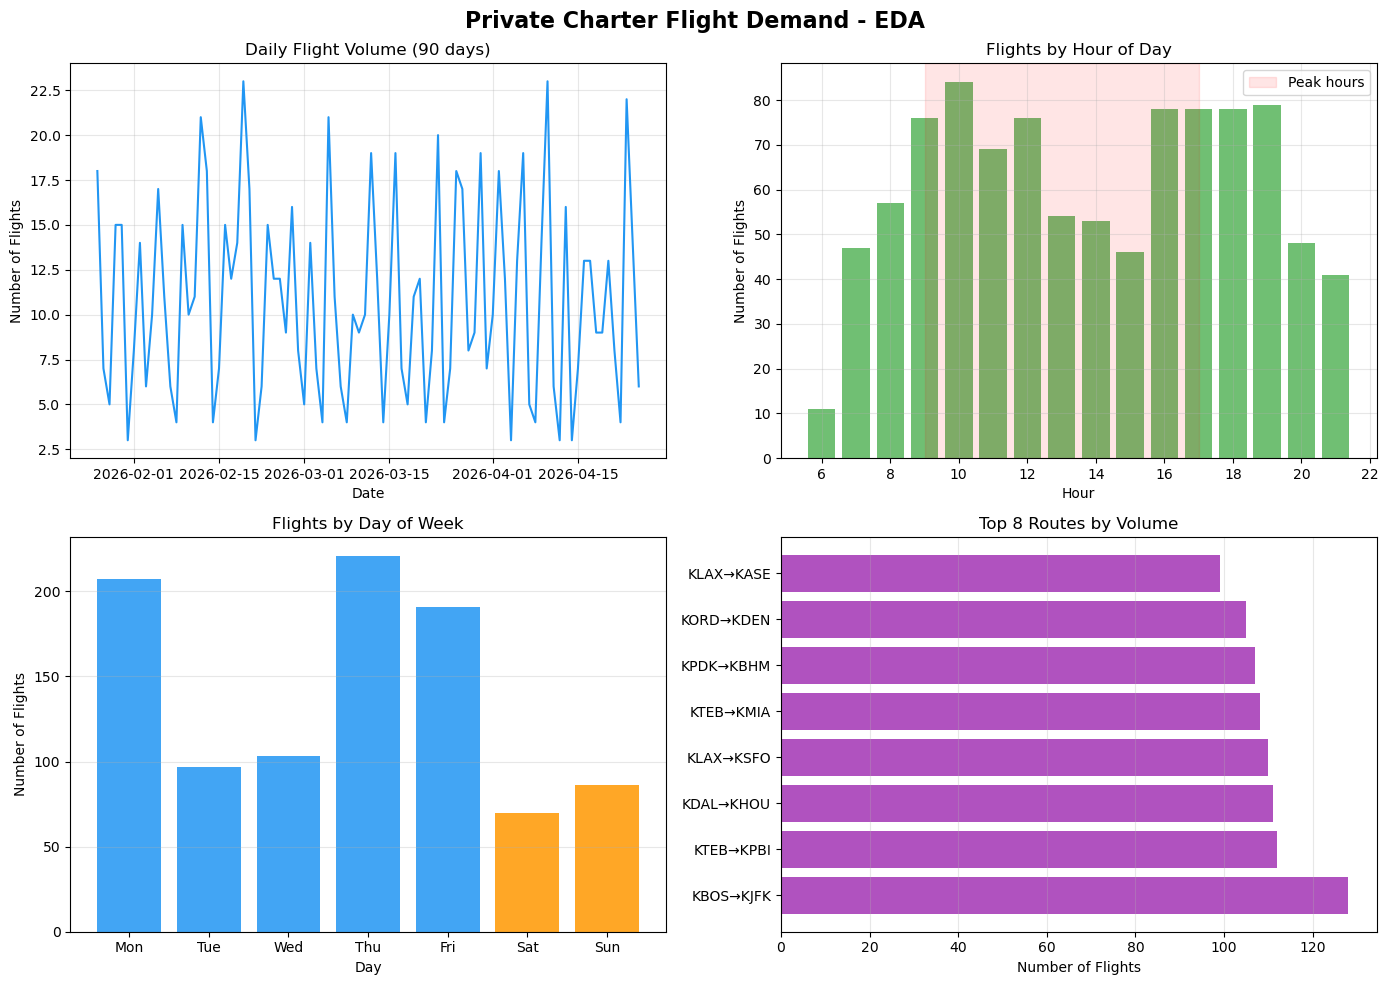

✅ EDA charts saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Private Charter Flight Demand - EDA", fontsize=16, fontweight="bold")

# Plot 1: Daily flight volume
daily = df.groupby("date").size().reset_index(name="flights")
axes[0,0].plot(daily["date"], daily["flights"], color="#2196F3", linewidth=1.5)
axes[0,0].set_title("Daily Flight Volume (90 days)")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Number of Flights")
axes[0,0].grid(alpha=0.3)

# Plot 2: Flights by hour of day
hour_counts = df.groupby("hour").size()
axes[0,1].bar(hour_counts.index, hour_counts.values, color="#4CAF50", alpha=0.8)
axes[0,1].set_title("Flights by Hour of Day")
axes[0,1].set_xlabel("Hour")
axes[0,1].set_ylabel("Number of Flights")
axes[0,1].axvspan(9, 17, alpha=0.1, color="red", label="Peak hours")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Plot 3: Flights by day of week
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_counts = df.groupby("weekday").size()
colors = ["#2196F3"]*5 + ["#FF9800"]*2
axes[1,0].bar(day_names, weekday_counts.values, color=colors, alpha=0.85)
axes[1,0].set_title("Flights by Day of Week")
axes[1,0].set_xlabel("Day")
axes[1,0].set_ylabel("Number of Flights")
axes[1,0].grid(alpha=0.3, axis="y")

# Plot 4: Top routes
top_routes = df.groupby(["origin","destination"]).size().nlargest(8)
route_labels = [f"{o}→{d}" for o,d in top_routes.index]
axes[1,1].barh(route_labels, top_routes.values, color="#9C27B0", alpha=0.8)
axes[1,1].set_title("Top 8 Routes by Volume")
axes[1,1].set_xlabel("Number of Flights")
axes[1,1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA charts saved!")

In [8]:
# Aggregate to daily demand
daily = df.groupby("date").size().reset_index(name="y")
daily = daily.rename(columns={"date": "ds"})

print(f"Training data: {len(daily)} days")
print(f"Avg daily flights: {daily['y'].mean():.1f}")
print(f"Max daily flights: {daily['y'].max()}")

# Train/test split — last 14 days as test
train = daily[:-14]
test = daily[-14:]

# Build and train model
model = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
)
model.fit(train)
print("\n✅ Prophet model trained!")

Training data: 90 days
Avg daily flights: 10.8
Max daily flights: 23


16:43:06 - cmdstanpy - INFO - Chain [1] start processing
16:43:10 - cmdstanpy - INFO - Chain [1] done processing



✅ Prophet model trained!


In [9]:
# Forecast 30 days ahead (14 test + 16 future)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Evaluate on test set
test_forecast = forecast[forecast["ds"].isin(test["ds"])]
mae = mean_absolute_error(test["y"].values, test_forecast["yhat"].values)
rmse = np.sqrt(mean_squared_error(test["y"].values, test_forecast["yhat"].values))

print("=== Model Performance ===")
print(f"MAE  (Mean Absolute Error): {mae:.2f} flights/day")
print(f"RMSE (Root Mean Sq Error):  {rmse:.2f} flights/day")
print(f"Avg actual demand:          {test['y'].mean():.2f} flights/day")
print(f"Accuracy (approx):          {(1 - mae/test['y'].mean())*100:.1f}%")

=== Model Performance ===
MAE  (Mean Absolute Error): 2.73 flights/day
RMSE (Root Mean Sq Error):  3.24 flights/day
Avg actual demand:          10.00 flights/day
Accuracy (approx):          72.7%


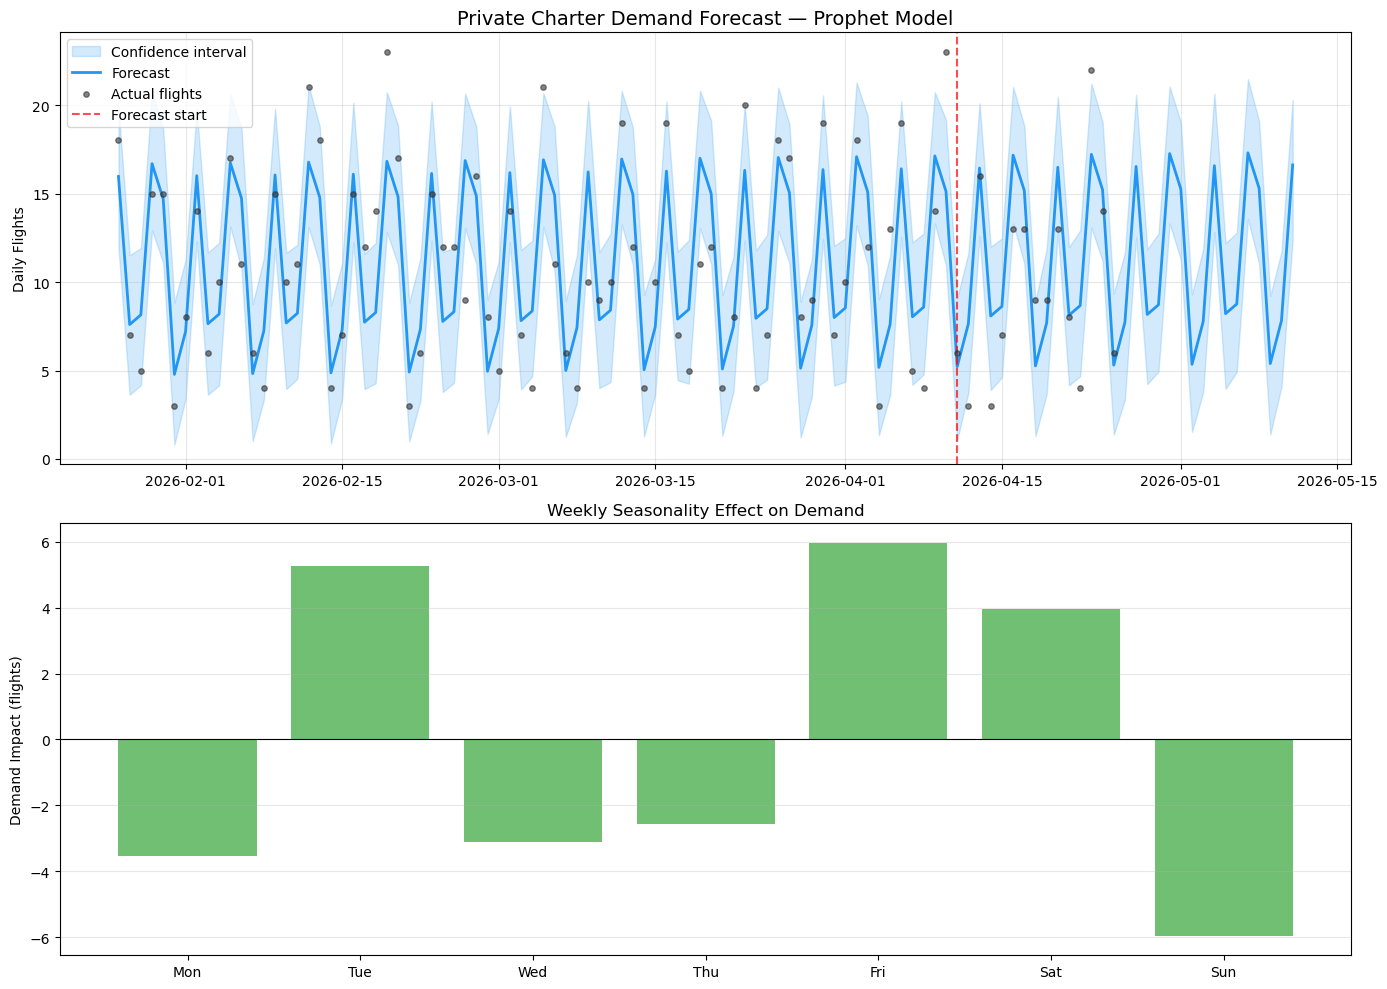

✅ Forecast chart saved!


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- Plot 1: Full forecast ---
ax1.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                 alpha=0.2, color="#2196F3", label="Confidence interval")
ax1.plot(forecast["ds"], forecast["yhat"], color="#2196F3",
         linewidth=2, label="Forecast")
ax1.scatter(daily["ds"], daily["y"], color="#333333",
            s=15, alpha=0.6, label="Actual flights", zorder=5)
ax1.axvline(x=train["ds"].max(), color="red",
            linestyle="--", alpha=0.7, label="Forecast start")
ax1.set_title("Private Charter Demand Forecast — Prophet Model", fontsize=14)
ax1.set_ylabel("Daily Flights")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Plot 2: Weekly seasonality component ---
weekly = model.predict(
    model.make_future_dataframe(periods=7)
)[["ds", "weekly"]].tail(7)
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax2.bar(day_names, weekly["weekly"].values, color="#4CAF50", alpha=0.8)
ax2.set_title("Weekly Seasonality Effect on Demand")
ax2.set_ylabel("Demand Impact (flights)")
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("forecast_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Forecast chart saved!")

In [11]:
# Save forecast output
output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
output.columns = ["date", "predicted_flights", "lower_bound", "upper_bound"]
output["predicted_flights"] = output["predicted_flights"].clip(lower=0).round(1)
output.to_csv("forecast_output.csv", index=False)

# Business insights
future_only = output.tail(16)
peak_day = future_only.loc[future_only["predicted_flights"].idxmax()]
low_day  = future_only.loc[future_only["predicted_flights"].idxmin()]

print("=" * 45)
print("   BUSINESS INSIGHTS — CHARTER DEMAND")
print("=" * 45)
print(f"\n📈 Avg forecast demand (next 16 days): {future_only['predicted_flights'].mean():.1f} flights/day")
print(f"🔺 Peak day predicted: {peak_day['date'].strftime('%A, %b %d')} ({peak_day['predicted_flights']:.0f} flights)")
print(f"🔻 Low  day predicted: {low_day['date'].strftime('%A, %b %d')}  ({low_day['predicted_flights']:.0f} flights)")
print(f"\n💡 Recommendation: Position aircraft at high-volume")
print(f"   routes (KLAX→KSFO, KTEB→KPBI) on peak days")
print(f"\n✅ Forecast saved to forecast_output.csv")

   BUSINESS INSIGHTS — CHARTER DEMAND

📈 Avg forecast demand (next 16 days): 11.4 flights/day
🔺 Peak day predicted: Thursday, Apr 30 (17 flights)
🔻 Low  day predicted: Saturday, May 02  (5 flights)

💡 Recommendation: Position aircraft at high-volume
   routes (KLAX→KSFO, KTEB→KPBI) on peak days

✅ Forecast saved to forecast_output.csv
